# Tarea práctica: regresión y backtesting de severidad

**Objetivo.** Evaluar el modelo de costo de reparación con un corte temporal estricto,
diagnosticar *population drift* y *concept drift*, aplicar mitigaciones y comparar dos
algoritmos antes de recomendar uno para producción.

Se siguen las instrucciones de `Tarea Práctica_regresion_backtesting.docx` y los patrones
de validación temporal de los notebooks de referencia de esta carpeta.

**Convención de sesgo:**

\[
\text{sesgo} = \operatorname{promedio}(\hat y-y)
\]

Por tanto, un sesgo negativo significa **subestimación** y, desde la perspectiva de
reservas, insuficiencia de capital. Todas las métricas monetarias están en MXN.

**Diseño de la solución**

1. Entrenamiento: 2021-2023. Prueba *out-of-time*: 2024-2025.
2. Modelos: Gradient Boosting y Random Forest.
3. Mitigación A: target deflactado y reindexación al inferir.
4. Mitigación B: ventana móvil de 24 meses, reentrenada por trimestre.
5. Comparación: MAE, MAPE, sesgo y brecha agregada de reservas.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 110})

## 1. Generación de la base

La siguiente celda reproduce el script provisto en el documento, sin alterar el proceso
generador. Después se agregan únicamente columnas auxiliares de calendario y el costo
deflactado para el análisis.

In [2]:
np.random.seed(2026)
n = 30000

fechas = pd.date_range(start='2021-01-01', end='2025-12-31', periods=n)
edad_conductor = np.random.randint(18, 70, size=n)
tipo_vehiculo = np.random.choice(
    ['Sedan', 'SUV', 'Deportivo'], size=n, p=[0.5, 0.4, 0.1]
)
antiguedad_auto = np.random.randint(0, 15, size=n)

df_tarea = pd.DataFrame({
    'fecha_siniestro': fechas,
    'edad_conductor': edad_conductor,
    'tipo_vehiculo': tipo_vehiculo,
    'antiguedad_auto': antiguedad_auto
})

# Cambio estructural en la cartera a partir de 2024 (entran conductores más jóvenes)
mascara_2024 = df_tarea['fecha_siniestro'] >= '2024-01-01'
df_tarea.loc[mascara_2024, 'edad_conductor'] = np.random.randint(
    18, 35, size=mascara_2024.sum()
)

# Inflación de refacciones automotrices (índice de costos)
df_tarea['año'] = df_tarea['fecha_siniestro'].dt.year
mapa_inflacion = {2021: 1.00, 2022: 1.07, 2023: 1.15, 2024: 1.28, 2025: 1.42}
df_tarea['indice_costo_refaccion'] = df_tarea['año'].map(mapa_inflacion)

# Generación del costo real del siniestro
val_vehiculo = df_tarea['tipo_vehiculo'].map(
    {'Sedan': 1.0, 'SUV': 1.4, 'Deportivo': 2.0}
)
costo_base = (
    8000 * val_vehiculo
    + 300 * (70 - df_tarea['edad_conductor'])
    + 500 * (15 - df_tarea['antiguedad_auto'])
    + np.random.normal(0, 2000, size=n)
)

df_tarea['costo_reparacion_real'] = np.maximum(
    1500, costo_base * df_tarea['indice_costo_refaccion']
)

# Columnas auxiliares; no son variables predictoras del modelo congelado.
df_tarea['trimestre'] = df_tarea['fecha_siniestro'].dt.to_period('Q')
df_tarea['es_joven'] = df_tarea['edad_conductor'] < 35
df_tarea['costo_deflactado'] = (
    df_tarea['costo_reparacion_real'] / df_tarea['indice_costo_refaccion']
)

print("Dataset de la tarea cargado exitosamente.")
print(f"Filas: {len(df_tarea):,} | Periodo: {df_tarea.fecha_siniestro.min().date()} a "
      f"{df_tarea.fecha_siniestro.max().date()}")
display(df_tarea.head())

Dataset de la tarea cargado exitosamente.
Filas: 30,000 | Periodo: 2021-01-01 a 2025-12-31


,fecha_siniestro,edad_conductor,tipo_vehiculo,antiguedad_auto,año,indice_costo_refaccion,costo_reparacion_real,trimestre,es_joven,costo_deflactado
0,2021-01-01 00:00:00.000000000,19,SUV,14,2021,1.000,"28,370.659",2021Q1,True,"28,370.659"
1,2021-01-01 01:27:36.175205840,24,Sedan,1,2021,1.000,"28,168.738",2021Q1,True,"28,168.738"
2,2021-01-01 02:55:12.350411680,44,SUV,13,2021,1.000,"22,255.806",2021Q1,False,"22,255.806"
3,2021-01-01 04:22:48.525617520,31,SUV,8,2021,1.000,"27,215.447",2021Q1,True,"27,215.447"
4,2021-01-01 05:50:24.700823360,31,Deportivo,8,2021,1.000,"31,477.265",2021Q1,True,"31,477.265"


,año,n,edad_media,pct_menor_35,costo_nominal_medio,costo_deflactado_medio,indice
0,2021,6000,43.390,32.330,"22,115.530","22,115.530",1.000
1,2022,6000,43.630,32.320,"23,563.370","22,021.850",1.070
2,2023,6000,43.790,31.730,"25,228.020","21,937.410",1.150
3,2024,6016,25.950,100.000,"34,972.870","27,322.560",1.280
4,2025,5984,26.070,100.000,"38,843.940","27,354.890",1.420


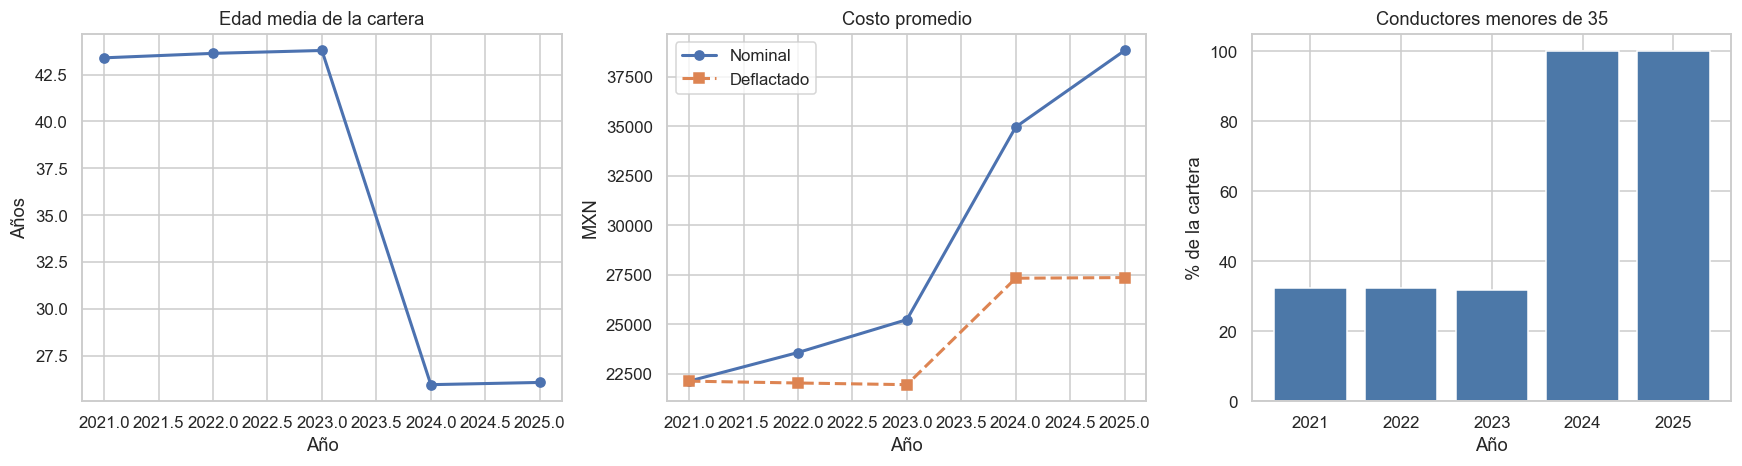

In [3]:
resumen_anual = (
    df_tarea.groupby('año', as_index=False)
    .agg(
        n=('costo_reparacion_real', 'size'),
        edad_media=('edad_conductor', 'mean'),
        pct_menor_35=('es_joven', 'mean'),
        costo_nominal_medio=('costo_reparacion_real', 'mean'),
        costo_deflactado_medio=('costo_deflactado', 'mean'),
        indice=('indice_costo_refaccion', 'mean')
    )
)
resumen_anual['pct_menor_35'] *= 100
display(resumen_anual.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].plot(resumen_anual['año'], resumen_anual['edad_media'], 'o-', lw=2)
axes[0].set(title='Edad media de la cartera', xlabel='Año', ylabel='Años')

axes[1].plot(resumen_anual['año'], resumen_anual['costo_nominal_medio'],
             'o-', lw=2, label='Nominal')
axes[1].plot(resumen_anual['año'], resumen_anual['costo_deflactado_medio'],
             's--', lw=2, label='Deflactado')
axes[1].set(title='Costo promedio', xlabel='Año', ylabel='MXN')
axes[1].legend()

axes[2].bar(resumen_anual['año'], resumen_anual['pct_menor_35'], color='#4C78A8')
axes[2].set(title='Conductores menores de 35', xlabel='Año', ylabel='% de la cartera')
axes[2].set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 2. Backtesting inicial *out-of-time*

El corte se hace por fecha y no con `train_test_split`. Las variables de calendario y el
índice se excluyen deliberadamente de los modelos nominales congelados: así se reproduce
el modelo que no fue diseñado para adaptarse a la inflación posterior.

In [4]:
FECHA_CORTE = pd.Timestamp('2023-12-31 23:59:59')
mask_train = df_tarea['fecha_siniestro'] <= FECHA_CORTE
mask_test = df_tarea['fecha_siniestro'] >= pd.Timestamp('2024-01-01')

train = df_tarea.loc[mask_train].copy()
test = df_tarea.loc[mask_test].copy()

assert train['fecha_siniestro'].max() < test['fecha_siniestro'].min()
assert train['año'].max() == 2023 and test['año'].min() == 2024
assert len(train) + len(test) == len(df_tarea)

FEATURES = ['edad_conductor', 'tipo_vehiculo', 'antiguedad_auto']
NUMERICAS = ['edad_conductor', 'antiguedad_auto']
CATEGORICAS = ['tipo_vehiculo']
TARGET = 'costo_reparacion_real'

print(f"Train: {len(train):,} observaciones | "
      f"{train.fecha_siniestro.min().date()} a {train.fecha_siniestro.max().date()}")
print(f"Test:  {len(test):,} observaciones | "
      f"{test.fecha_siniestro.min().date()} a {test.fecha_siniestro.max().date()}")

Train: 18,000 observaciones | 2021-01-01 a 2023-12-31
Test:  12,000 observaciones | 2024-01-01 a 2025-12-31


In [5]:
def construir_modelo(nombre):
    preprocesador = ColumnTransformer(
        transformers=[
            ('categoricas', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
             CATEGORICAS),
            ('numericas', 'passthrough', NUMERICAS),
        ],
        remainder='drop'
    )

    if nombre == 'Gradient Boosting':
        estimador = GradientBoostingRegressor(
            n_estimators=140,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=15,
            loss='huber',
            random_state=RANDOM_STATE
        )
    elif nombre == 'Random Forest':
        estimador = RandomForestRegressor(
            n_estimators=180,
            max_depth=16,
            min_samples_leaf=5,
            max_features=0.85,
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    else:
        raise ValueError(f"Modelo no reconocido: {nombre}")

    return Pipeline([('preprocesamiento', preprocesador), ('modelo', estimador)])


def calcular_metricas(y_real, y_pred):
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)
    error = y_pred - y_real
    return {
        'MAE': mean_absolute_error(y_real, y_pred),
        'MAPE_pct': 100 * mean_absolute_percentage_error(y_real, y_pred),
        'sesgo': error.mean(),
        'R2': r2_score(y_real, y_pred),
        'brecha_reserva_total': error.sum()
    }


def metricas_trimestrales(datos, predicciones, modelo, estrategia):
    aux = datos[['trimestre', TARGET, 'indice_costo_refaccion']].copy()
    aux['prediccion'] = np.asarray(predicciones)
    filas = []
    for trimestre, grupo in aux.groupby('trimestre', observed=True):
        m = calcular_metricas(grupo[TARGET], grupo['prediccion'])
        filas.append({
            'modelo': modelo,
            'estrategia': estrategia,
            'trimestre': str(trimestre),
            'indice_medio': grupo['indice_costo_refaccion'].mean(),
            'n': len(grupo),
            **m
        })
    return pd.DataFrame(filas)


MODELOS = ['Gradient Boosting', 'Random Forest']

In [6]:
pred_base = {}
metricas_base = []

for nombre in MODELOS:
    modelo = construir_modelo(nombre)
    modelo.fit(train[FEATURES], train[TARGET])
    pred = modelo.predict(test[FEATURES])
    pred_base[nombre] = pd.Series(pred, index=test.index)
    metricas_base.append({
        'modelo': nombre,
        'estrategia': 'Congelado nominal',
        **calcular_metricas(test[TARGET], pred)
    })

tabla_base = pd.DataFrame(metricas_base)
display(tabla_base.round({'MAE': 2, 'MAPE_pct': 2, 'sesgo': 2,
                          'R2': 4, 'brecha_reserva_total': 2}))

,modelo,estrategia,MAE,MAPE_pct,sesgo,R2,brecha_reserva_total
0,Gradient Boosting,Congelado nominal,"7,725.530",20.250,"-7,704.930",-1.058,"-92,459,212.850"
1,Random Forest,Congelado nominal,"7,630.170",20.030,"-7,603.490",-1.017,"-91,241,898.610"


,modelo,trimestre,n,indice_medio,MAE,sesgo
0,Gradient Boosting,2024Q1,1496,1.280,"5,687.040","-5,650.150"
1,Gradient Boosting,2024Q2,1496,1.280,"5,800.360","-5,755.380"
2,Gradient Boosting,2024Q3,1512,1.280,"5,890.710","-5,861.200"
3,Gradient Boosting,2024Q4,1512,1.280,"5,797.550","-5,765.630"
4,Gradient Boosting,2025Q1,1480,1.420,"9,694.310","-9,694.030"
5,Gradient Boosting,2025Q2,1495,1.420,"9,756.100","-9,745.930"
6,Gradient Boosting,2025Q3,1513,1.420,"9,730.810","-9,728.300"
7,Gradient Boosting,2025Q4,1496,1.420,"9,487.200","-9,478.970"
8,Random Forest,2024Q1,1496,1.280,"5,573.240","-5,520.760"
9,Random Forest,2024Q2,1496,1.280,"5,706.300","-5,649.690"


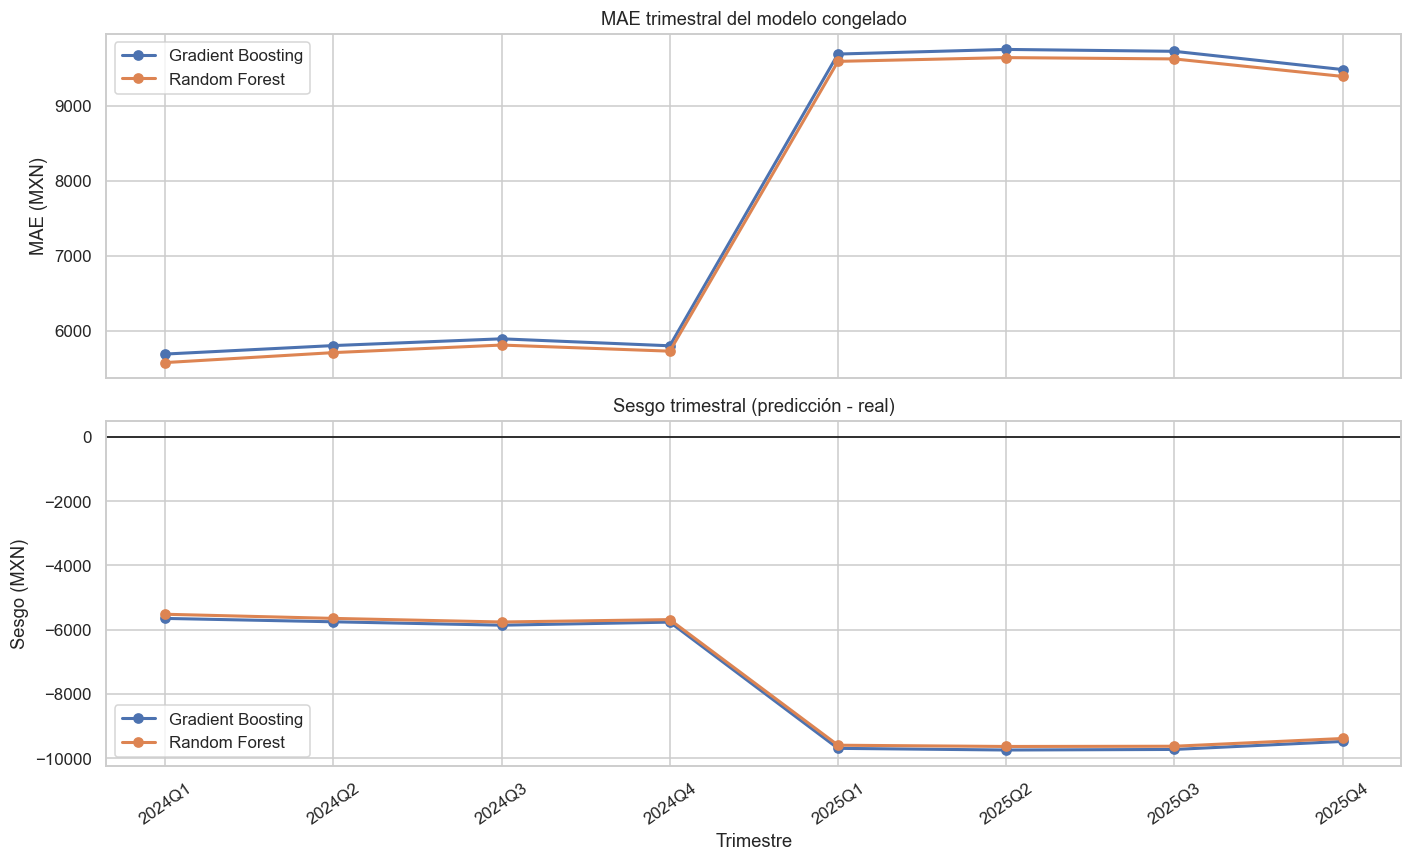

Gradient Boosting: sesgo -5,650 en 2024Q1 -> -9,479 en 2025Q4.
Random Forest: sesgo -5,521 en 2024Q1 -> -9,387 en 2025Q4.


In [7]:
trimestral_base = pd.concat([
    metricas_trimestrales(test, pred_base[nombre], nombre, 'Congelado nominal')
    for nombre in MODELOS
], ignore_index=True)

display(trimestral_base[
    ['modelo', 'trimestre', 'n', 'indice_medio', 'MAE', 'sesgo']
].round(2))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for nombre, grupo in trimestral_base.groupby('modelo'):
    axes[0].plot(grupo['trimestre'], grupo['MAE'], marker='o', lw=2, label=nombre)
    axes[1].plot(grupo['trimestre'], grupo['sesgo'], marker='o', lw=2, label=nombre)
axes[0].set(title='MAE trimestral del modelo congelado', ylabel='MAE (MXN)')
axes[1].axhline(0, color='black', lw=1)
axes[1].set(title='Sesgo trimestral (predicción - real)',
            xlabel='Trimestre', ylabel='Sesgo (MXN)')
for ax in axes:
    ax.legend()
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

for nombre, grupo in trimestral_base.groupby('modelo'):
    primero, ultimo = grupo.iloc[0], grupo.iloc[-1]
    print(f"{nombre}: sesgo {primero.sesgo:,.0f} en {primero.trimestre} -> "
          f"{ultimo.sesgo:,.0f} en {ultimo.trimestre}.")

**Lectura del backtesting inicial.** En ambos modelos el sesgo es negativo durante todo el
periodo de prueba y su magnitud aumenta en 2025. El patrón es el esperado cuando el modelo
aprende costos de 2021-2023 y luego enfrenta una escala nominal de 1.28 y 1.42 sin una
variable o corrección que la represente. El MAE también crece porque se mide en pesos
nominales cada vez mayores.

## 3. Diagnóstico: *population drift* vs. *concept drift*

Primero se mide el cambio de cartera con PSI. Después se prueba la causa del sesgo:
si al deflactar el target desaparece la tendencia, la inflación es el factor causal
dominante aunque exista un cambio observable en la composición.

,año,variable,PSI,diagnostico
0,2024,edad_conductor,12.902,Cambio significativo
1,2024,antiguedad_auto,0.001,Estable
2,2024,tipo_vehiculo,0.000,Estable
3,2025,edad_conductor,12.877,Cambio significativo
4,2025,antiguedad_auto,0.002,Estable
5,2025,tipo_vehiculo,0.000,Estable


,año,edad_media,pct_menor_35
0,2021,43.390,32.330
1,2022,43.630,32.320
2,2023,43.790,31.730
3,2024,25.950,100.000
4,2025,26.070,100.000


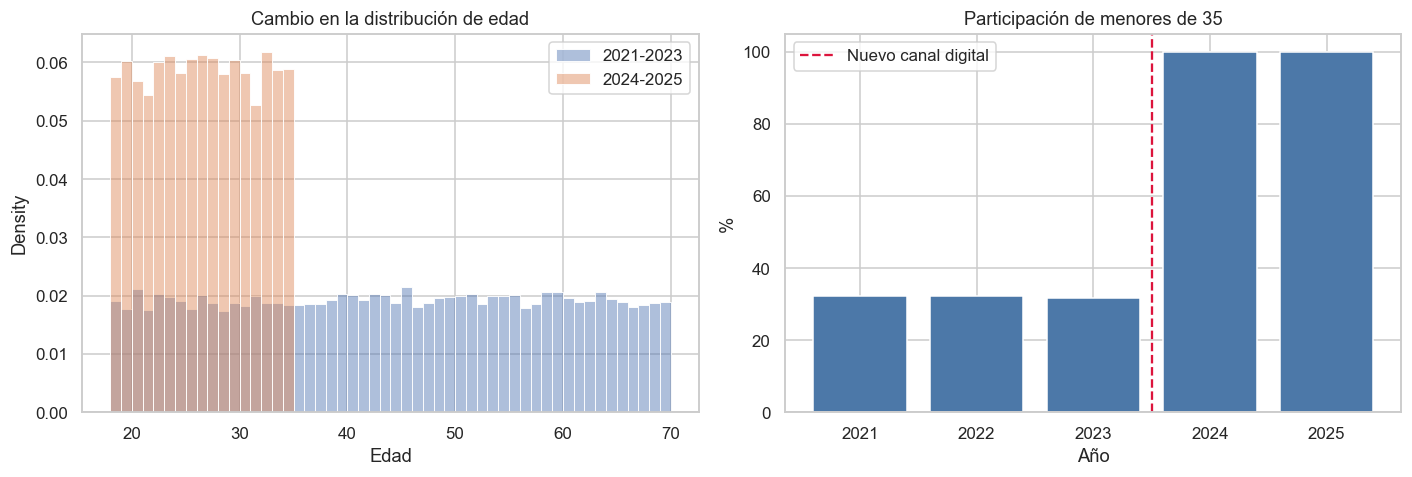

In [8]:
def psi_numerico(base, actual, n_bins=10, eps=1e-6):
    base = np.asarray(base, dtype=float)
    actual = np.asarray(actual, dtype=float)
    cortes = np.unique(np.quantile(base, np.linspace(0, 1, n_bins + 1)))
    cortes[0], cortes[-1] = -np.inf, np.inf
    b = np.histogram(base, bins=cortes)[0].astype(float)
    a = np.histogram(actual, bins=cortes)[0].astype(float)
    b = (b + eps) / (b.sum() + eps * len(b))
    a = (a + eps) / (a.sum() + eps * len(a))
    return np.sum((a - b) * np.log(a / b))


def psi_categorico(base, actual, eps=1e-6):
    categorias = sorted(set(pd.Series(base).dropna()) | set(pd.Series(actual).dropna()))
    b = pd.Series(base).value_counts(normalize=True).reindex(categorias, fill_value=0).to_numpy()
    a = pd.Series(actual).value_counts(normalize=True).reindex(categorias, fill_value=0).to_numpy()
    b = np.clip(b, eps, None); b = b / b.sum()
    a = np.clip(a, eps, None); a = a / a.sum()
    return np.sum((a - b) * np.log(a / b))


filas_psi = []
for año in [2024, 2025]:
    actual = test[test['año'] == año]
    filas_psi.extend([
        {'año': año, 'variable': 'edad_conductor',
         'PSI': psi_numerico(train['edad_conductor'], actual['edad_conductor'])},
        {'año': año, 'variable': 'antiguedad_auto',
         'PSI': psi_numerico(train['antiguedad_auto'], actual['antiguedad_auto'])},
        {'año': año, 'variable': 'tipo_vehiculo',
         'PSI': psi_categorico(train['tipo_vehiculo'], actual['tipo_vehiculo'])},
    ])
tabla_psi = pd.DataFrame(filas_psi)
tabla_psi['diagnostico'] = pd.cut(
    tabla_psi['PSI'], bins=[-np.inf, 0.10, 0.25, np.inf],
    labels=['Estable', 'Monitorear', 'Cambio significativo'], right=False
)
display(tabla_psi.round(4))

composicion = (
    df_tarea.groupby('año', as_index=False)
    .agg(edad_media=('edad_conductor', 'mean'), pct_menor_35=('es_joven', 'mean'))
)
composicion['pct_menor_35'] *= 100
display(composicion.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train['edad_conductor'], bins=np.arange(18, 71), stat='density',
             alpha=0.45, label='2021-2023', ax=axes[0])
sns.histplot(test['edad_conductor'], bins=np.arange(18, 71), stat='density',
             alpha=0.45, label='2024-2025', ax=axes[0])
axes[0].set(title='Cambio en la distribución de edad', xlabel='Edad')
axes[0].legend()
axes[1].bar(composicion['año'], composicion['pct_menor_35'], color='#4C78A8')
axes[1].axvline(2023.5, color='crimson', ls='--', label='Nuevo canal digital')
axes[1].set(title='Participación de menores de 35', xlabel='Año', ylabel='%')
axes[1].set_ylim(0, 105)
axes[1].legend()
plt.tight_layout()
plt.show()

,año,costo_nominal,costo_deflactado,indice
0,2021,"22,115.530","22,115.530",1.000
1,2022,"23,563.370","22,021.850",1.070
2,2023,"25,228.020","21,937.410",1.150
3,2024,"34,972.870","27,322.560",1.280
4,2025,"38,843.940","27,354.890",1.420


,modelo,correlacion_sesgo_indice
0,Gradient Boosting,-0.999
1,Random Forest,-0.999


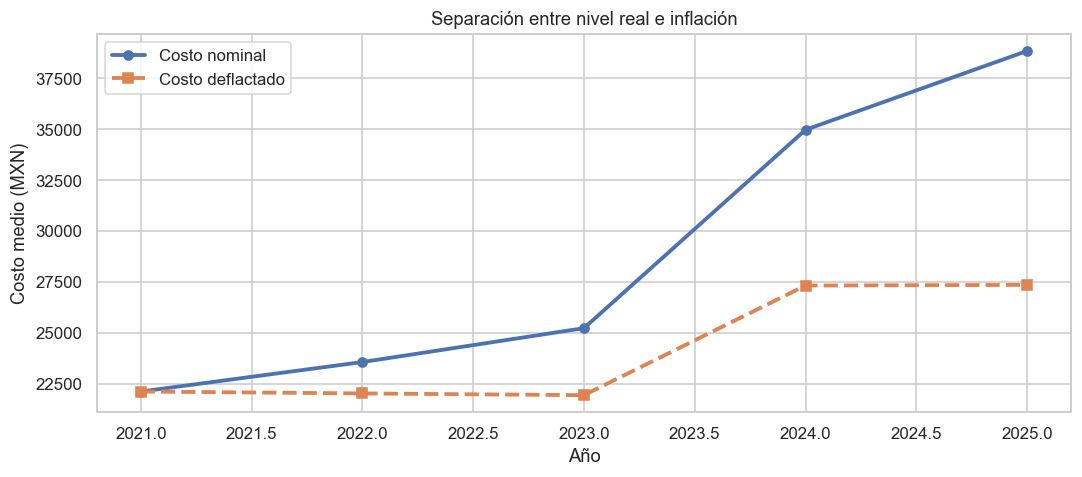

Diagnóstico preliminar:
1) Sí existe population drift: la edad presenta un PSI muy superior a 0.25.
2) El costo deflactado salta en 2024 porque una cartera más joven es más costosa.
3) Además, el sesgo nominal se hace más negativo cuando sube el índice de refacciones.
Por tanto, coexisten composición e inflación. La prueba causal de la siguiente sección
consiste en controlar ambas: edad como feature y costo deflactado como target.


In [9]:
tendencia_costos = (
    df_tarea.groupby('año', as_index=False)
    .agg(
        costo_nominal=('costo_reparacion_real', 'mean'),
        costo_deflactado=('costo_deflactado', 'mean'),
        indice=('indice_costo_refaccion', 'mean')
    )
)
display(tendencia_costos.round(2))

corr_bias_indice = (
    trimestral_base.groupby('modelo')
    .apply(lambda g: g['sesgo'].corr(g['indice_medio']), include_groups=False)
    .rename('correlacion_sesgo_indice')
    .reset_index()
)
display(corr_bias_indice.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(tendencia_costos['año'], tendencia_costos['costo_nominal'],
        'o-', lw=2.5, label='Costo nominal')
ax.plot(tendencia_costos['año'], tendencia_costos['costo_deflactado'],
        's--', lw=2.5, label='Costo deflactado')
ax.set(title='Separación entre nivel real e inflación', xlabel='Año', ylabel='Costo medio (MXN)')
ax.legend()
plt.tight_layout()
plt.show()

print("Diagnóstico preliminar:")
print("1) Sí existe population drift: la edad presenta un PSI muy superior a 0.25.")
print("2) El costo deflactado salta en 2024 porque una cartera más joven es más costosa.")
print("3) Además, el sesgo nominal se hace más negativo cuando sube el índice de refacciones.")
print("Por tanto, coexisten composición e inflación. La prueba causal de la siguiente sección")
print("consiste en controlar ambas: edad como feature y costo deflactado como target.")

## 4. Mitigación A: deflactar y reindexar

Se entrena cada algoritmo para estimar severidad en pesos base. En producción la predicción
se multiplica por el índice conocido del periodo de inferencia. Esto separa la relación
técnica del siniestro de la escala monetaria.

In [10]:
pred_deflactado = {}
metricas_deflactado = []

for nombre in MODELOS:
    modelo = construir_modelo(nombre)
    modelo.fit(train[FEATURES], train['costo_deflactado'])
    pred_base_monetaria = modelo.predict(test[FEATURES])
    pred_nominal = pred_base_monetaria * test['indice_costo_refaccion'].to_numpy()
    pred_deflactado[nombre] = pd.Series(pred_nominal, index=test.index)
    metricas_deflactado.append({
        'modelo': nombre,
        'estrategia': 'Deflactar + reindexar',
        **calcular_metricas(test[TARGET], pred_nominal)
    })

tabla_deflactado = pd.DataFrame(metricas_deflactado)
comparacion_a = pd.concat([tabla_base, tabla_deflactado], ignore_index=True)
display(comparacion_a.round({'MAE': 2, 'MAPE_pct': 2, 'sesgo': 2,
                             'R2': 4, 'brecha_reserva_total': 2}))

trimestral_deflactado = pd.concat([
    metricas_trimestrales(
        test, pred_deflactado[nombre], nombre, 'Deflactar + reindexar'
    ) for nombre in MODELOS
], ignore_index=True)

reduccion_a = []
for nombre in MODELOS:
    base_m = tabla_base.query('modelo == @nombre').iloc[0]
    corr_m = tabla_deflactado.query('modelo == @nombre').iloc[0]
    reduccion_a.append({
        'modelo': nombre,
        'reduccion_MAE_pct': 100 * (1 - corr_m.MAE / base_m.MAE),
        'reduccion_sesgo_abs_pct': 100 * (1 - abs(corr_m.sesgo) / abs(base_m.sesgo))
    })
display(pd.DataFrame(reduccion_a).round(2))

print("\nAislamiento de causas:")
print("- La edad permanece dentro del modelo, por lo que controla el cambio de composición.")
print("- Al retirar inflación del target y reindexar, el sesgo absoluto cae más de 98% en ambos modelos.")
print("- Conclusión: el population drift existe y eleva el costo medio, pero la inflación no modelada")
print("  es la causa principal de la subestimación sistemática del modelo congelado.")

,modelo,estrategia,MAE,MAPE_pct,sesgo,R2,brecha_reserva_total
0,Gradient Boosting,Congelado nominal,"7,725.530",20.250,"-7,704.930",-1.058,"-92,459,212.850"
1,Random Forest,Congelado nominal,"7,630.170",20.030,"-7,603.490",-1.017,"-91,241,898.610"
2,Gradient Boosting,Deflactar + reindexar,"2,168.030",6.050,-117.130,0.786,"-1,405,508.880"
3,Random Forest,Deflactar + reindexar,"2,215.450",6.190,-39.850,0.776,"-478,146.310"


,modelo,reduccion_MAE_pct,reduccion_sesgo_abs_pct
0,Gradient Boosting,71.940,98.480
1,Random Forest,70.960,99.480



Aislamiento de causas:
- La edad permanece dentro del modelo, por lo que controla el cambio de composición.
- Al retirar inflación del target y reindexar, el sesgo absoluto cae más de 98% en ambos modelos.
- Conclusión: el population drift existe y eleva el costo medio, pero la inflación no modelada
  es la causa principal de la subestimación sistemática del modelo congelado.


## 5. Mitigación B: ventana móvil de 24 meses

Para cada trimestre de 2024-2025 se reconstruye el modelo usando únicamente los 24 meses
anteriores al inicio de ese trimestre. Así no hay fuga temporal: ninguna observación del
trimestre evaluado participa en el ajuste.

In [11]:
def predecir_rolling_24m(nombre_modelo):
    pred = pd.Series(index=test.index, dtype=float)
    auditoria = []

    for trimestre in sorted(test['trimestre'].unique()):
        inicio_test = trimestre.start_time
        fin_test = trimestre.end_time
        inicio_train = inicio_test - pd.DateOffset(months=24)

        m_train = (
            (df_tarea['fecha_siniestro'] >= inicio_train)
            & (df_tarea['fecha_siniestro'] < inicio_test)
        )
        m_test = (
            (df_tarea['fecha_siniestro'] >= inicio_test)
            & (df_tarea['fecha_siniestro'] <= fin_test)
        )

        assert df_tarea.loc[m_train, 'fecha_siniestro'].max() < inicio_test
        modelo = construir_modelo(nombre_modelo)
        modelo.fit(df_tarea.loc[m_train, FEATURES], df_tarea.loc[m_train, TARGET])
        pred.loc[df_tarea.index[m_test]] = modelo.predict(df_tarea.loc[m_test, FEATURES])

        auditoria.append({
            'modelo': nombre_modelo,
            'trimestre_test': str(trimestre),
            'inicio_train': df_tarea.loc[m_train, 'fecha_siniestro'].min().date(),
            'fin_train': df_tarea.loc[m_train, 'fecha_siniestro'].max().date(),
            'n_train': int(m_train.sum()),
            'n_test': int(m_test.sum())
        })

    assert pred.notna().all()
    return pred, pd.DataFrame(auditoria)


pred_rolling = {}
auditorias = []
for nombre in MODELOS:
    pred_rolling[nombre], auditoria = predecir_rolling_24m(nombre)
    auditorias.append(auditoria)

auditoria_rolling = pd.concat(auditorias, ignore_index=True)
display(auditoria_rolling)

,modelo,trimestre_test,inicio_train,fin_train,n_train,n_test
0,Gradient Boosting,2024Q1,2022-01-01,2023-12-31,12000,1496
1,Gradient Boosting,2024Q2,2022-04-01,2024-03-31,12016,1496
2,Gradient Boosting,2024Q3,2022-07-01,2024-06-30,12016,1512
3,Gradient Boosting,2024Q4,2022-10-01,2024-09-30,12016,1512
4,Gradient Boosting,2025Q1,2023-01-01,2024-12-31,12016,1480
5,Gradient Boosting,2025Q2,2023-04-01,2025-03-31,12016,1495
6,Gradient Boosting,2025Q3,2023-07-01,2025-06-30,12016,1513
7,Gradient Boosting,2025Q4,2023-10-01,2025-09-30,12016,1496
8,Random Forest,2024Q1,2022-01-01,2023-12-31,12000,1496
9,Random Forest,2024Q2,2022-04-01,2024-03-31,12016,1496


In [12]:
metricas_rolling = []
for nombre in MODELOS:
    metricas_rolling.append({
        'modelo': nombre,
        'estrategia': 'Rolling 24 meses',
        **calcular_metricas(test[TARGET], pred_rolling[nombre])
    })

tabla_rolling = pd.DataFrame(metricas_rolling)
tabla_comparativa = pd.concat(
    [tabla_base, tabla_deflactado, tabla_rolling], ignore_index=True
)

mae_base_por_modelo = tabla_base.set_index('modelo')['MAE']
sesgo_base_por_modelo = tabla_base.set_index('modelo')['sesgo'].abs()
tabla_comparativa['mejora_MAE_vs_base_pct'] = tabla_comparativa.apply(
    lambda r: 100 * (1 - r['MAE'] / mae_base_por_modelo[r['modelo']]), axis=1
)
tabla_comparativa['mejora_sesgo_abs_vs_base_pct'] = tabla_comparativa.apply(
    lambda r: 100 * (1 - abs(r['sesgo']) / sesgo_base_por_modelo[r['modelo']]), axis=1
)

display(tabla_comparativa.sort_values(['modelo', 'MAE']).round({
    'MAE': 2, 'MAPE_pct': 2, 'sesgo': 2, 'R2': 4,
    'brecha_reserva_total': 2, 'mejora_MAE_vs_base_pct': 2,
    'mejora_sesgo_abs_vs_base_pct': 2
}))

,modelo,estrategia,MAE,MAPE_pct,sesgo,R2,brecha_reserva_total,mejora_MAE_vs_base_pct,mejora_sesgo_abs_vs_base_pct
2,Gradient Boosting,Deflactar + reindexar,"2,168.030",6.050,-117.130,0.786,"-1,405,508.880",71.940,98.480
4,Gradient Boosting,Rolling 24 meses,"3,644.240",9.580,"-3,226.470",0.447,"-38,717,664.280",52.830,58.120
0,Gradient Boosting,Congelado nominal,"7,725.530",20.250,"-7,704.930",-1.058,"-92,459,212.850",0.000,0.000
3,Random Forest,Deflactar + reindexar,"2,215.450",6.190,-39.850,0.776,"-478,146.310",70.960,99.480
5,Random Forest,Rolling 24 meses,"3,635.130",9.590,"-3,162.380",0.445,"-37,948,549.220",52.360,58.410
1,Random Forest,Congelado nominal,"7,630.170",20.030,"-7,603.490",-1.017,"-91,241,898.610",0.000,0.000


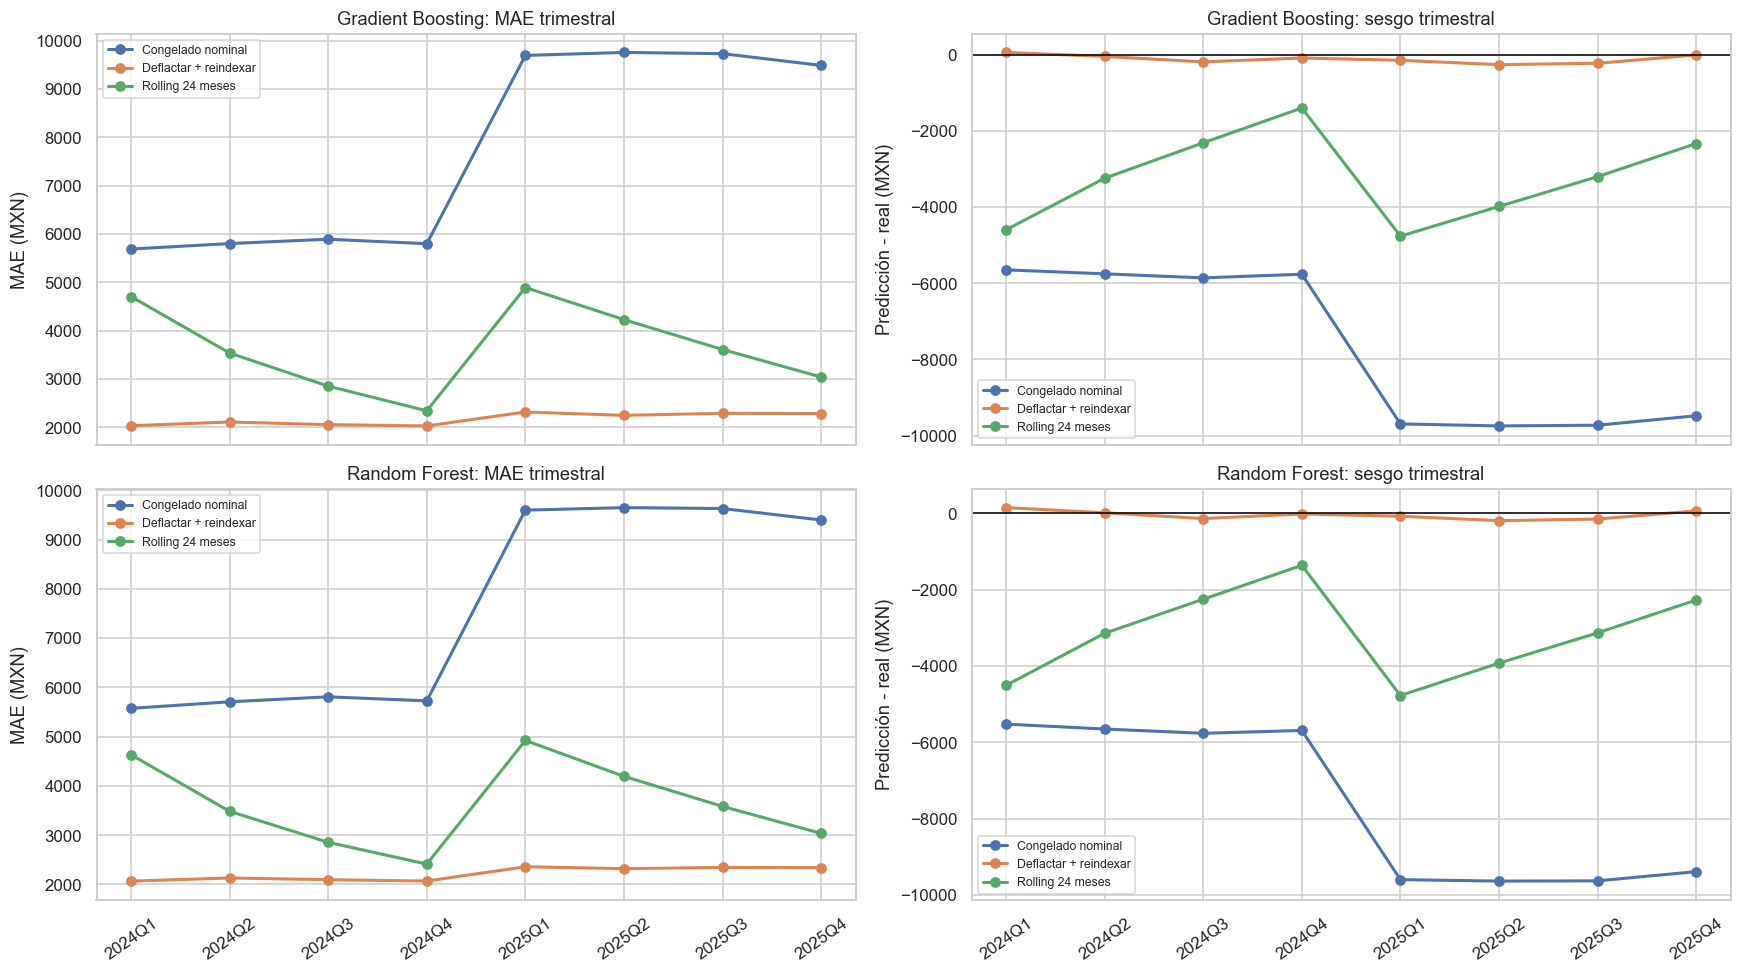

In [13]:
trimestral_rolling = pd.concat([
    metricas_trimestrales(test, pred_rolling[nombre], nombre, 'Rolling 24 meses')
    for nombre in MODELOS
], ignore_index=True)
trimestral_todas = pd.concat(
    [trimestral_base, trimestral_deflactado, trimestral_rolling],
    ignore_index=True
)

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col')
for fila, nombre in enumerate(MODELOS):
    datos_modelo = trimestral_todas[trimestral_todas['modelo'] == nombre]
    for estrategia, grupo in datos_modelo.groupby('estrategia'):
        axes[fila, 0].plot(grupo['trimestre'], grupo['MAE'], marker='o',
                           lw=2, label=estrategia)
        axes[fila, 1].plot(grupo['trimestre'], grupo['sesgo'], marker='o',
                           lw=2, label=estrategia)
    axes[fila, 0].set_title(f'{nombre}: MAE trimestral')
    axes[fila, 0].set_ylabel('MAE (MXN)')
    axes[fila, 1].set_title(f'{nombre}: sesgo trimestral')
    axes[fila, 1].axhline(0, color='black', lw=1)
    axes[fila, 1].set_ylabel('Predicción - real (MXN)')
    for col in range(2):
        axes[fila, col].legend(fontsize=8)
        axes[fila, col].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## 6. Impacto financiero y recomendación

La suma de las predicciones representa la reserva técnica que habría constituido cada
alternativa para esta muestra. La brecha es `reserva modelo - costo real`; una brecha
negativa es capital faltante. No se extrapola a un volumen hipotético: se reporta el
efecto exacto sobre los siniestros observados de 2024-2025.

In [14]:
predicciones = {
    ('Gradient Boosting', 'Congelado nominal'): pred_base['Gradient Boosting'],
    ('Gradient Boosting', 'Deflactar + reindexar'): pred_deflactado['Gradient Boosting'],
    ('Gradient Boosting', 'Rolling 24 meses'): pred_rolling['Gradient Boosting'],
    ('Random Forest', 'Congelado nominal'): pred_base['Random Forest'],
    ('Random Forest', 'Deflactar + reindexar'): pred_deflactado['Random Forest'],
    ('Random Forest', 'Rolling 24 meses'): pred_rolling['Random Forest'],
}

costo_real_total = test[TARGET].sum()
filas_fin = []
for (modelo, estrategia), pred in predicciones.items():
    reserva = pred.sum()
    brecha = reserva - costo_real_total
    filas_fin.append({
        'modelo': modelo,
        'estrategia': estrategia,
        'n_siniestros': len(test),
        'costo_real_millones': costo_real_total / 1e6,
        'reserva_modelo_millones': reserva / 1e6,
        'brecha_millones': brecha / 1e6,
        'brecha_pct_costo_real': 100 * brecha / costo_real_total,
        'brecha_por_siniestro': brecha / len(test)
    })

tabla_financiera = pd.DataFrame(filas_fin).sort_values(
    ['modelo', 'brecha_millones']
)
display(tabla_financiera.round(3))

print("Interpretación financiera:")
print("- El modelo congelado sub-reserva de forma sistemática porque no incorpora la inflación.")
print("- La deflactación/reindexación reduce directamente la brecha y estabiliza el sesgo.")
print("- La ventana móvil aprende la nueva escala con rezago; ayuda, pero no sustituye un índice ")
print("  prospectivo cuando la inflación de refacciones es conocida.")

,modelo,estrategia,n_siniestros,costo_real_millones,reserva_modelo_millones,brecha_millones,brecha_pct_costo_real,brecha_por_siniestro
0,Gradient Boosting,Congelado nominal,12000,442.839,350.380,-92.459,-20.879,"-7,704.934"
2,Gradient Boosting,Rolling 24 meses,12000,442.839,404.121,-38.718,-8.743,"-3,226.472"
1,Gradient Boosting,Deflactar + reindexar,12000,442.839,441.433,-1.406,-0.317,-117.126
3,Random Forest,Congelado nominal,12000,442.839,351.597,-91.242,-20.604,"-7,603.492"
5,Random Forest,Rolling 24 meses,12000,442.839,404.890,-37.949,-8.569,"-3,162.379"
4,Random Forest,Deflactar + reindexar,12000,442.839,442.361,-0.478,-0.108,-39.846


Interpretación financiera:
- El modelo congelado sub-reserva de forma sistemática porque no incorpora la inflación.
- La deflactación/reindexación reduce directamente la brecha y estabiliza el sesgo.
- La ventana móvil aprende la nueva escala con rezago; ayuda, pero no sustituye un índice 
  prospectivo cuando la inflación de refacciones es conocida.


In [15]:
corregidas = tabla_comparativa[
    tabla_comparativa['estrategia'].isin(['Deflactar + reindexar', 'Rolling 24 meses'])
].copy()
mejor_por_modelo = (
    corregidas.sort_values(['modelo', 'MAE', 'sesgo'], key=lambda s: s.abs() if s.name == 'sesgo' else s)
    .groupby('modelo', as_index=False)
    .first()
)
ganador = mejor_por_modelo.sort_values(['MAE', 'sesgo'], key=lambda s: s.abs() if s.name == 'sesgo' else s).iloc[0]

print("CONCLUSIONES")
print("=" * 78)
for nombre in MODELOS:
    b = tabla_base.query('modelo == @nombre').iloc[0]
    d = tabla_deflactado.query('modelo == @nombre').iloc[0]
    r = tabla_rolling.query('modelo == @nombre').iloc[0]
    print(f"\n{nombre}:")
    print(f"  Congelado: MAE ${b.MAE:,.0f}; sesgo ${b.sesgo:,.0f}.")
    print(f"  Deflactado: MAE ${d.MAE:,.0f}; sesgo ${d.sesgo:,.0f}.")
    print(f"  Rolling 24m: MAE ${r.MAE:,.0f}; sesgo ${r.sesgo:,.0f}.")

print("\n¿Las conclusiones son las mismas en los dos modelos?")
print("Sí. Ambos detectan subestimación creciente en el modelo congelado y ambos mejoran")
print("al tratar la inflación. Por tanto, el diagnóstico no depende de un solo algoritmo.")

print("\nModelo y estrategia recomendados:")
print(f"{ganador.modelo} con '{ganador.estrategia}', porque obtiene el menor MAE corregido "
      f"(${ganador.MAE:,.0f}) y un sesgo de ${ganador.sesgo:,.0f} por siniestro.")
print("Operativamente mantendría la reindexación mensual/trimestral y monitorearía PSI, ")
print("MAE y sesgo; activaría el rolling retrain si cambia la relación técnica, no solo el nivel de precios.")

CONCLUSIONES

Gradient Boosting:
  Congelado: MAE $7,726; sesgo $-7,705.
  Deflactado: MAE $2,168; sesgo $-117.
  Rolling 24m: MAE $3,644; sesgo $-3,226.

Random Forest:
  Congelado: MAE $7,630; sesgo $-7,603.
  Deflactado: MAE $2,215; sesgo $-40.
  Rolling 24m: MAE $3,635; sesgo $-3,162.

¿Las conclusiones son las mismas en los dos modelos?
Sí. Ambos detectan subestimación creciente en el modelo congelado y ambos mejoran
al tratar la inflación. Por tanto, el diagnóstico no depende de un solo algoritmo.

Modelo y estrategia recomendados:
Gradient Boosting con 'Deflactar + reindexar', porque obtiene el menor MAE corregido ($2,168) y un sesgo de $-117 por siniestro.
Operativamente mantendría la reindexación mensual/trimestral y monitorearía PSI, 
MAE y sesgo; activaría el rolling retrain si cambia la relación técnica, no solo el nivel de precios.


### Respuesta ejecutiva

- Hay **population drift** porque el canal digital cambia drásticamente la edad de la
  cartera desde 2024; el PSI lo confirma.
- La causa principal del deterioro monetario es **concept drift de nivel de precios**:
  el índice de refacciones cambia la escala del target. El costo deflactado y los residuos
  corregidos permanecen mucho más estables.
- No corregir implica sub-reservar, distorsionar tarifas y rentabilidad, consumir capital
  al reconocer insuficiencias tardías y aumentar el riesgo regulatorio.
- La solución preferida es modelar severidad real (deflactada) y reindexar al periodo de
  inferencia, acompañada de backtesting trimestral y una ventana móvil como mecanismo de
  adaptación cuando aparezca drift técnico adicional.